## 02 - Modeling & Imbalance Strategies

This notebook trains and evaluates:
- XGBoost
- LightGBM
- Hybrid (RandomForest feature selection + XGBoost)

It also compares imbalance strategies (SMOTE vs class weight) and compares standard vs cost-sensitive learning.

It loads the **real IEEE-CIS** training data from `data/raw/`.

In [1]:
import sys
sys.path.insert(0, "D:/mlops4/fraud-mlops")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import load_data, handle_missing_values, encode_categoricals, get_feature_target_split, time_based_train_test_split


TRANSACTIONS_CSV = "D:/mlops4/fraud-mlops/data/raw/train_transaction.csv"
IDENTITY_CSV = "D:/mlops4/fraud-mlops/data/raw/train_identity.csv"


df = load_data(TRANSACTIONS_CSV, IDENTITY_CSV)
df = handle_missing_values(df)
X, y = get_feature_target_split(df)

In [2]:
from sklearn.model_selection import train_test_split

from src.train import compare_imbalance_strategies, train_xgboost, train_lightgbm, train_hybrid
from src.evaluate import compare_all_models
from src.cost_sensitive import standard_vs_costsensitive_comparison

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train.shape, X_test.shape, y.mean()

((413378, 219), (177162, 219), np.float64(0.03499000914417313))

### Compare imbalance strategies (SMOTE vs class weight)

This prints a comparison table (Precision/Recall/F1/AUC-ROC).

In [3]:
imbalance_table = compare_imbalance_strategies(X_train, y_train, X_test, y_test)
imbalance_table[["precision", "recall", "f1", "auc_roc"]]

                     precision    recall        f1   auc_roc
strategy                                                    
SMOTE+XGBoost         0.197285  0.822875  0.318265  0.925757
ClassWeight+XGBoost   0.243815  0.818680  0.375731  0.936650


,precision,recall,f1,auc_roc
strategy,,,,
SMOTE+XGBoost,0.197285,0.822875,0.318265,0.925757
ClassWeight+XGBoost,0.243815,0.818680,0.375731,0.936650


### Train XGBoost, LightGBM, and Hybrid

In [4]:
xgb = train_xgboost(X_train, y_train, cost_sensitive=False)
lgbm = train_lightgbm(X_train, y_train, cost_sensitive=False)
hybrid = train_hybrid(X_train, y_train)

models = {"xgboost": xgb, "lightgbm": lgbm, "hybrid": hybrid}
comparison = compare_all_models(models, X_test, y_test)
comparison

[LightGBM] [Info] Number of positive: 14464, number of negative: 398914
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.109713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18318
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317083
[LightGBM] [Info] Start training from score -3.317083

=== xgboost ===
              precision    recall  f1-score   support

           0     0.9796    0.9984    0.9889    170963
           1     0.9054    0.4262    0.5796      6199

    accuracy                         0.9784    177162
   macro avg     0.9425    0.7123    0.7842    177162
weighted avg     0.9770    0.9784    0.9746    177162


=== lightgbm ===
              precision    recall  f1-score   support

           0     0.98

,precision,recall,f1,auc_roc
model,,,,
lightgbm,0.927242,0.530408,0.674808,0.957413
xgboost,0.905415,0.426198,0.579577,0.930901
hybrid,0.897023,0.413131,0.565717,0.925760


### Standard vs Cost-Sensitive (scale_pos_weight=50)

This prints business impact and saves `reports/cost_sensitive_comparison.csv`.

In [5]:
cs = standard_vs_costsensitive_comparison(X_train, y_train, X_test, y_test)
cs


=== Business Impact ===
                             item  count  unit_cost  total_cost
0  False Negatives (missed fraud)   3487      500.0   1743500.0
1  False Positives (false alarms)    271       10.0      2710.0
2                           Total   3758        NaN   1746210.0

=== Business Impact ===
                             item  count  unit_cost  total_cost
0  False Negatives (missed fraud)    778      500.0    389000.0
1  False Positives (false alarms)  25644       10.0    256440.0
2                           Total  26422        NaN    645440.0

=== Standard vs Cost-Sensitive Comparison ===
                              precision    recall        f1   auc_roc  total_cost  fraud_loss  false_alarm_cost
model                                                                                                          
xgboost_standard               0.909152  0.437490  0.590721  0.933888   1746210.0   1743500.0            2710.0
xgboost_cost_sensitive_spw50   0.174505  0.874496  0.29

,precision,recall,f1,auc_roc,total_cost,fraud_loss,false_alarm_cost
model,,,,,,,
xgboost_standard,0.909152,0.437490,0.590721,0.933888,1746210.0,1743500.0,2710.0
xgboost_cost_sensitive_spw50,0.174505,0.874496,0.290951,0.940768,645440.0,389000.0,256440.0


### Plots

Confusion matrices and ROC curves were saved to `reports/` by `compare_all_models()`.

In [6]:
import glob

sorted(glob.glob("reports/*confusion_matrix.png"))[:10]

['reports\\hybrid_confusion_matrix.png',
 'reports\\lightgbm_confusion_matrix.png',
 'reports\\xgboost_confusion_matrix.png']

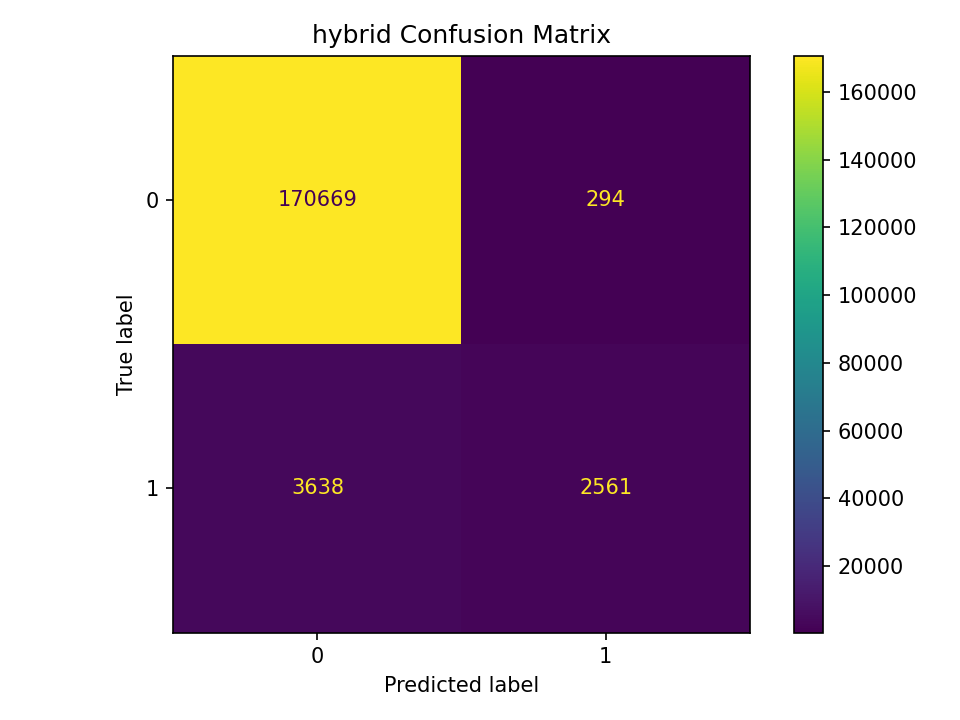

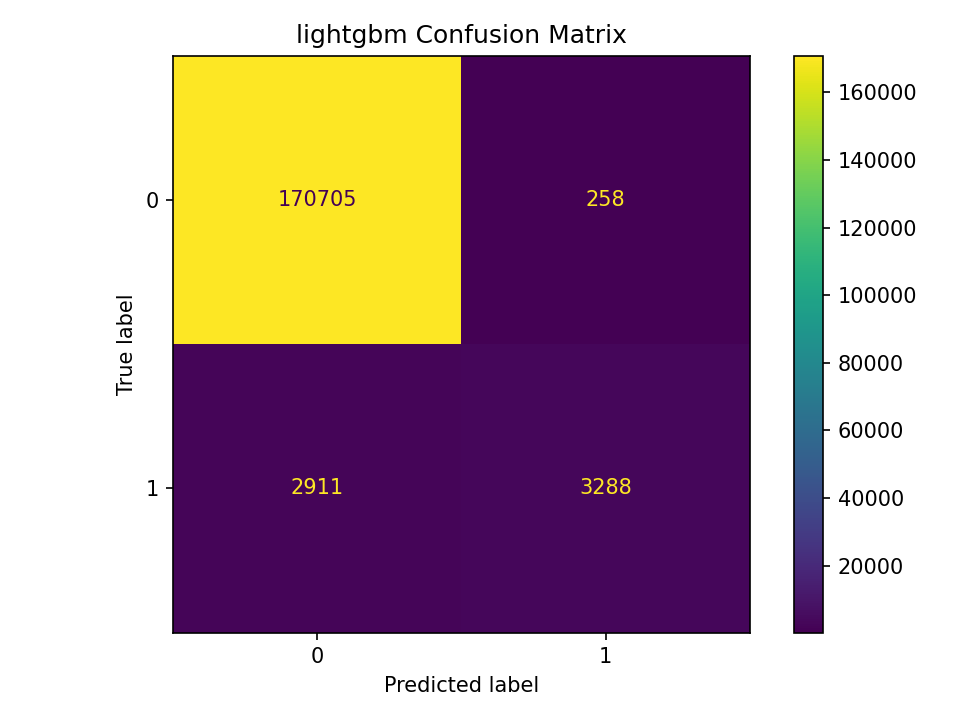

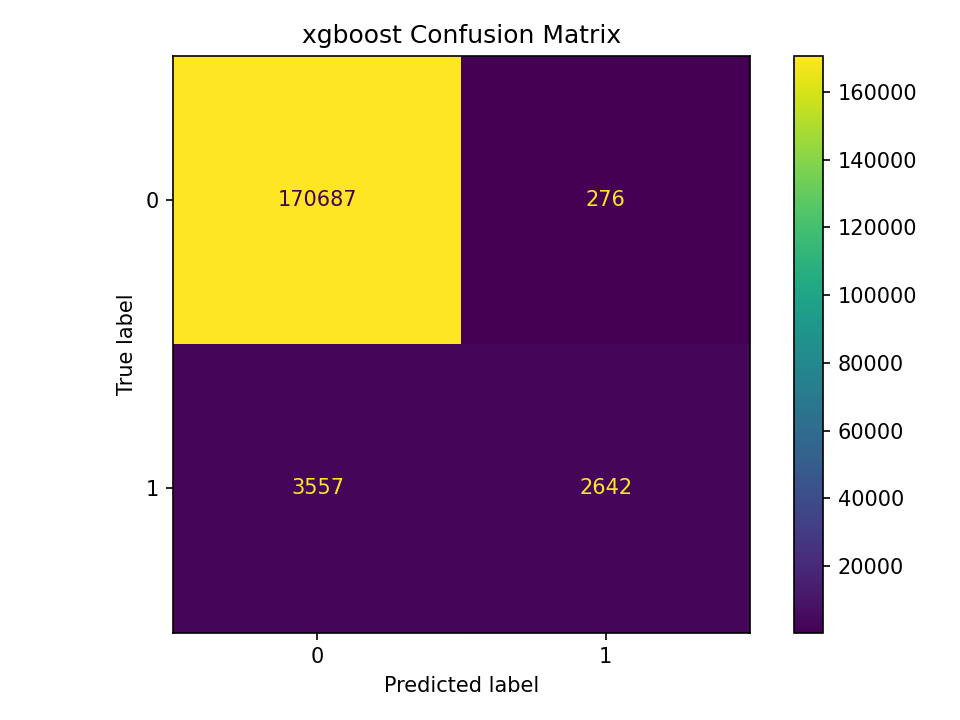

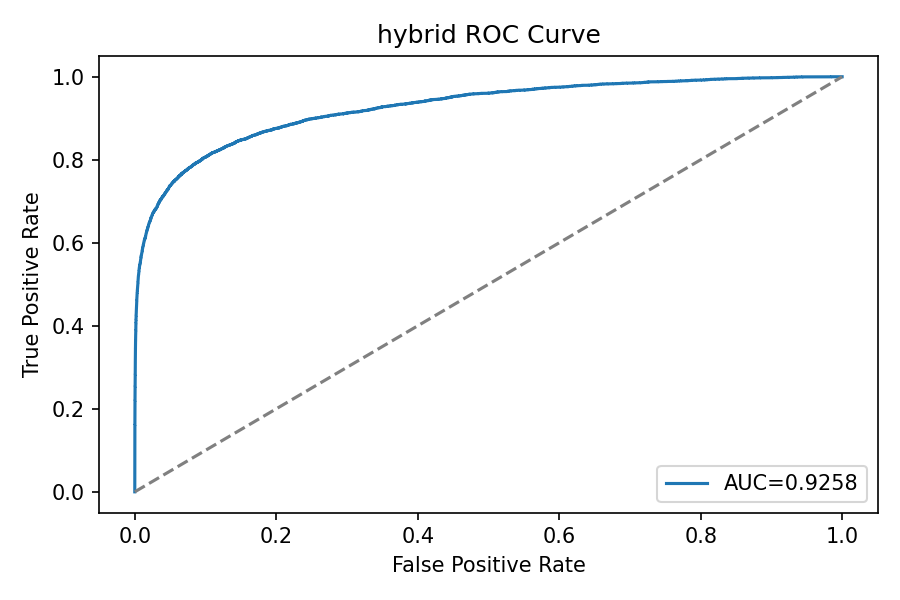

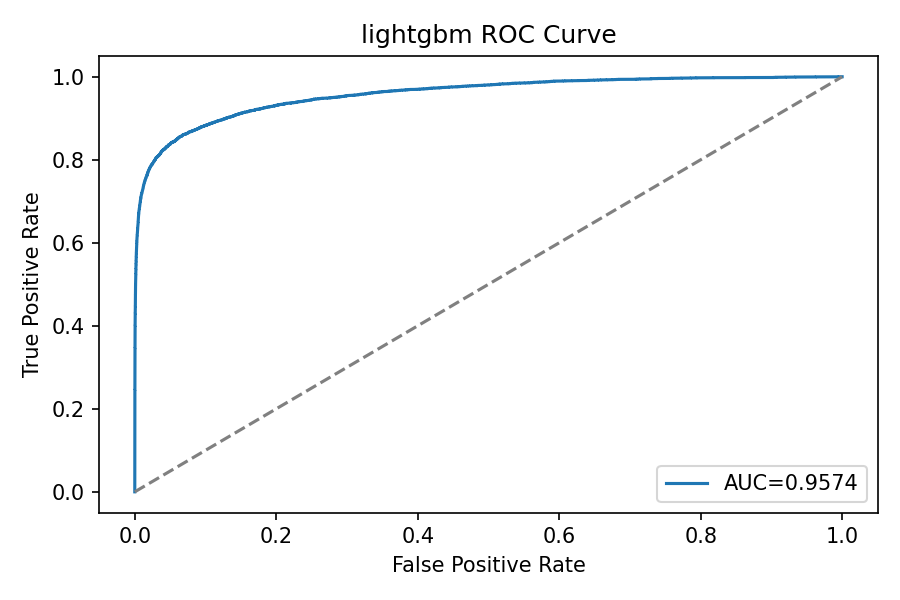

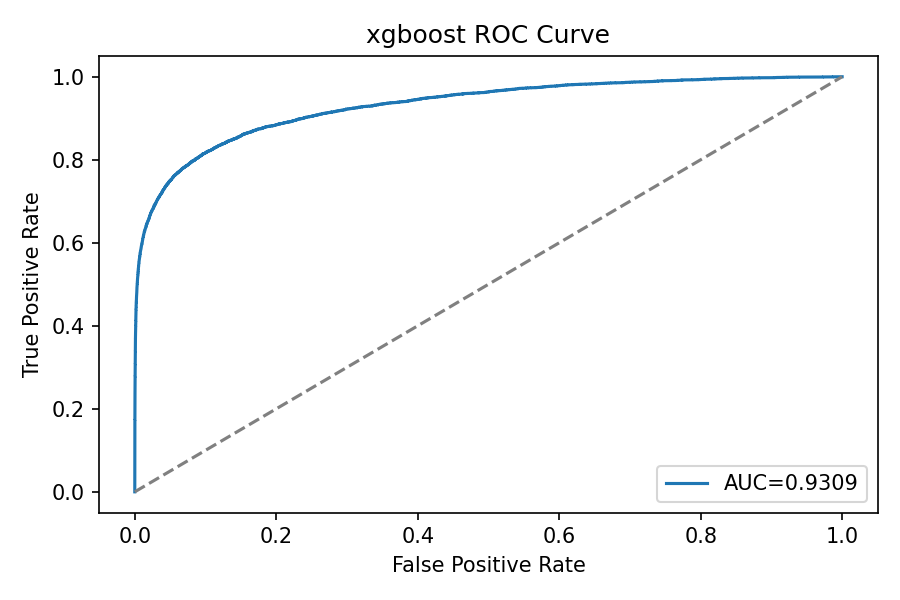

In [7]:
from IPython.display import Image, display
import glob
for f in glob.glob("reports/*confusion_matrix.png"):
    display(Image(f))
for f in glob.glob("reports/*roc*.png"):
    display(Image(f))

In [9]:
import sys
sys.path.insert(0, "D:/mlops4/fraud-mlops")
import joblib, os
from src.data_utils import load_data, handle_missing_values, get_feature_target_split
from src.train import train_xgboost, train_lightgbm, train_hybrid
from sklearn.model_selection import train_test_split

# Reload data
df = load_data(
    "D:/mlops4/fraud-mlops/data/raw/train_transaction.csv",
    "D:/mlops4/fraud-mlops/data/raw/train_identity.csv"
)
df = handle_missing_values(df)
X, y = get_feature_target_split(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

os.makedirs("D:/mlops4/fraud-mlops/models", exist_ok=True)

print("Training XGBoost...")
xgb = train_xgboost(X_train, y_train)
joblib.dump(xgb, "D:/mlops4/fraud-mlops/models/xgboost_model.joblib")
print("XGBoost saved!")

print("Training LightGBM...")
lgbm = train_lightgbm(X_train, y_train)
joblib.dump(lgbm, "D:/mlops4/fraud-mlops/models/lightgbm_model.joblib")
print("LightGBM saved!")

print("Training Hybrid...")
hybrid = train_hybrid(X_train, y_train)
joblib.dump(hybrid, "D:/mlops4/fraud-mlops/models/hybrid_model.joblib")
print("Hybrid saved!")

print("ALL DONE:", os.listdir("D:/mlops4/fraud-mlops/models"))

Training XGBoost...
XGBoost saved!
Training LightGBM...
[LightGBM] [Info] Number of positive: 14464, number of negative: 398914
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.157207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18318
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317083
[LightGBM] [Info] Start training from score -3.317083
LightGBM saved!
Training Hybrid...
Hybrid saved!
ALL DONE: ['hybrid_model.joblib', 'lightgbm_model.joblib', 'xgboost_model.joblib']
